<a href="https://colab.research.google.com/github/maucikamau/ZavrsniRad/blob/main/asd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Utjecaj pretprocesiranja funkcijskih MR slika na klasifikaciju poremećaja iz autističnog spektra


## Imports

In [ ]:
%pip install nilearn
%pip install nilearn[plotting]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 705.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.2 MB/s eta 0:00:00


In [ ]:
import glob
import warnings
import numpy as np
import pandas as pd

from scipy.stats import spearmanr
from numpy import interp
from itertools import cycle

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, roc_curve, auc, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import nilearn

# Opcionalno: yellowbrick za learning curve
try:
    from yellowbrick.model_selection import LearningCurve
    YELLOWBRICK_AVAILABLE = True
except ImportError:
    YELLOWBRICK_AVAILABLE = False
    print("Yellowbrick nije instaliran. Learning curve će koristiti sklearn.")

warnings.filterwarnings('ignore')

## Pomoćne funkcije

In [ ]:
def timeseries_to_connectivity(csv_path):
    """Pretvori vremenske serije u Spearman connectivity matricu."""
    df = pd.read_csv(csv_path, header=None)
    data = df.values
    corr_matrix, _ = spearmanr(data)
    corr_matrix = np.nan_to_num(corr_matrix)
    np.fill_diagonal(corr_matrix, 0)
    return corr_matrix


def flatten_upper_triangle(matrix):
    """Ekstrahiraj gornji trokut matrice (bez dijagonale)."""
    arr = np.array(matrix)
    n = arr.shape[0]
    triu_indices = np.triu_indices(n, k=1)
    return arr[triu_indices]

In [1]:
import numpy as np
from scipy.stats import spearmanr

def get_features_and_labels(abide_dataset, derivative_name):
    """
    Automatizira izračun Spearmanovih matrica i pripremu labela.
    """
    features_list = []
    labels_list = []

    # Pristupamo dinamički (npr. abide_dataset.rois_cc200)
    timeseries_data = getattr(abide_dataset, derivative_name)
    pheno_data = abide_dataset.phenotypic

    print(f"Obrađujem: {derivative_name}...")

    for i, (ts, label) in enumerate(zip(timeseries_data, pheno_data['DX_GROUP'])):

        if isinstance(ts, str):
            ts = np.loadtxt(ts)

        # spearmanr računa korelaciju po stupcima (regijama)
        corr_matrix, _ = spearmanr(ts)

        # Čišćenje matrice
        corr_matrix = np.nan_to_num(corr_matrix)
        np.fill_diagonal(corr_matrix, 0)

        # Vektorizacija (uzimanje gornjeg trokuta)
        flat_features = flatten_upper_triangle(corr_matrix)

        features_list.append(flat_features)
        labels_list.append(1 if label == 1 else 0) # 1=ASD, 0=TD

        if (i+1) % 200 == 0:
            print(f"  Obrađeno {i+1} subjekata...")

    return np.array(features_list), np.array(labels_list)

## Vizualizacijske funkcije

In [ ]:
def plot_confusion_matrix_detailed(y_true, y_pred, title, save_path=None):

    list_names = ['TD', 'ASD']
    cm = confusion_matrix(y_true, y_pred)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100

    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape

    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)

    cm_df = pd.DataFrame(cm)
    cm_df.index.name = 'Actual'
    cm_df.columns.name = 'Predicted'

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=annot, fmt='', cmap='rocket_r',
                xticklabels=list_names, yticklabels=list_names)
    plt.title(title)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    return cm

In [ ]:
def plot_learning_curve_sklearn(estimator, X, y, title='Learning Curve',
                                 cv=10, n_jobs=-1, save_path=None):

    train_sizes = np.linspace(0.1, 1.0, 10)

    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs,
        train_sizes=train_sizes, scoring='f1'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))

    plt.fill_between(train_sizes_abs, train_mean - train_std,
                     train_mean + train_std, alpha=0.1, color='steelblue')
    plt.fill_between(train_sizes_abs, test_mean - test_std,
                     test_mean + test_std, alpha=0.1, color='coral')

    plt.plot(train_sizes_abs, train_mean, 'o-', color='steelblue',
             label='Training score')
    plt.plot(train_sizes_abs, test_mean, 'o-', color='coral',
             label='Cross-validation score')

    plt.xlabel('Training Instances')
    plt.ylabel('Score')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Funkcija treniranje i evaulacije

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

def train_and_evaluate(X_train, y_train, X_test, y_test, dataset_name):
    """
    Treniraj modele s Pipelineom (Selekcija + Model) i GridSearchCV,
    te evaluiraj na test setu bez overfittinga i KeyErrora.
    """

    models = {

        'Logistic Regression': {
            'model': Pipeline([
                ('select', SelectKBest(score_func=f_classif)),
                ('model', LogisticRegression(random_state=42, max_iter=1000, penalty='l1', solver='liblinear'))
            ]),
            'params': {
                'select__k': [100, 200, 500],
                'model__C': [0.01, 0.05, 0.1, 1.0]
            }
        },

        'Random Forest': {
            'model': Pipeline([
                ('select', SelectKBest(score_func=f_classif)),
                ('model', RandomForestClassifier(random_state=42))
            ]),
            'params': {
                'select__k': [100, 200],
                'model__n_estimators': [100, 200],
                'model__max_depth': [5, 10, None]
            }
        },


        'Naive Bayes': {
            'model': Pipeline([
                ('select', SelectKBest(score_func=f_classif)),
                ('model', GaussianNB())
            ]),
            'params': {
                'select__k': [50, 100, 200],
                'model__var_smoothing': [1e-5, 1e-3, 1e-1]
            }
        },

        'MLP': {
            'model': Pipeline([
                ('select', SelectKBest(score_func=f_classif)),
                ('model', MLPClassifier(hidden_layer_sizes=(50,), alpha=0.001, random_state=42, max_iter=200))
            ]),
            'params': {
                'select__k': [50, 100, 200]
            }
        },
    }

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    results = []
    best_models = {}
    predictions = {}

    for name, config in models.items():
        print(f"\nTreniram {name} s ugrađenom selekcijom značajki...")

        # Sada config['model'] radi savršeno jer ključ postoji!
        grid = GridSearchCV(config['model'], config['params'],
                           cv=cv, scoring='f1', n_jobs=-1)
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        best_models[name] = best_model

        y_pred = best_model.predict(X_test)

        if hasattr(best_model, 'predict_proba'):
            y_prob = best_model.predict_proba(X_test)[:, 1]
        else:
            y_prob = y_pred

        predictions[name] = {
            'y_pred': y_pred,
            'y_prob': y_prob
        }

        results.append({
            'Model': name,
            'CV F1 (Optimizirano)': grid.best_score_,
            'Test AUC': roc_auc_score(y_test, y_prob),
            'Accuracy': accuracy_score(y_test, y_pred),
            'F1': f1_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'Best Params': str(grid.best_params_)
        })

        print(f"  CV F1: {grid.best_score_:.3f}, Test F1: {results[-1]['F1']:.3f}, Test AUC: {results[-1]['Test AUC']:.3f}")

    df_results = pd.DataFrame(results)

    print(f"\n{'='*60}")
    print(f"REZULTATI - {dataset_name}")
    print('='*60)
    print(df_results[['Model', 'Test AUC', 'Accuracy', 'F1']].to_string(index=False))

    return df_results, best_models, predictions

# Treniranje na ABIDE skupu
Korištenje 3 cjevovoda pretprocesiranja (CPAC, CCS, NIAK) sa i bez parametra GSR na atlasima CC200 i AAL.

### 1.1 Učitavanje podataka

In [ ]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 66.6 MB/s eta 0:00:00
ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [ ]:
# preuzimenje na Google disk
from nilearn.datasets import fetch_abide_pcp
from google.colab import drive
import os

drive.mount('/content/drive')

# izmijeniti i ponoviti za gsr=True

dir_path1 = '/content/drive/MyDrive/ABIDE'
if not os.path.exists(dir_path1):
    os.makedirs(dir_path1)

abide1 = fetch_abide_pcp(
    data_dir=dir_path1,
    derivatives=['rois_aal'], #'rois_aal' 'rois_cc200'
    pipeline='cpac',
    band_pass_filtering=True,
    global_signal_regression=False, #False True
    quality_checked=True
)
#print(f"[CPAC] Broj subjekata: {len(abide1.rois_cc200)}")
print(f"[CPAC] Broj subjekata: {len(abide1.rois_aal)}")
print(f"[CPAC] ASD: {sum(abide1.phenotypic['DX_GROUP']==1)}, TD: {sum(abide1.phenotypic['DX_GROUP']==2)}")

abide2 = fetch_abide_pcp(
    data_dir=dir_path1,
    derivatives=['rois_aal'],
    pipeline='ccs',
    band_pass_filtering=True,
    global_signal_regression=False,
    quality_checked=True
)
#print(f"[CCS] Broj subjekata: {len(abide2.rois_cc200)}")
print(f"[CCS] Broj subjekata: {len(abide2.rois_aal)}")
print(f"[CCS] ASD: {sum(abide2.phenotypic['DX_GROUP']==1)}, TD: {sum(abide2.phenotypic['DX_GROUP']==2)}")

abide3 = fetch_abide_pcp(
    data_dir=dir_path1,
    derivatives=['rois_aal'],
    pipeline='niak',
    band_pass_filtering=True,
    global_signal_regression=False,
    quality_checked=True
)
#print(f"[NIAK] Broj subjekata: {len(abide3.rois_cc200)}")
print(f"[NIAK] Broj subjekata: {len(abide3.rois_aal)}")
print(f"[NIAK] ASD: {sum(abide3.phenotypic['DX_GROUP']==1)}, TD: {sum(abide3.phenotypic['DX_GROUP']==2)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[fetch_abide_pcp] Dataset found in /content/drive/MyDrive/ABIDE_gsrFalse/ABIDE_pcp

[CPAC] Broj subjekata: 871
[CPAC] ASD: 403, TD: 468


[fetch_abide_pcp] Dataset found in /content/drive/MyDrive/ABIDE_gsrFalse/ABIDE_pcp

[CCS] Broj subjekata: 871
[CCS] ASD: 403, TD: 468


[fetch_abide_pcp] Dataset found in /content/drive/MyDrive/ABIDE_gsrFalse/ABIDE_pcp

[NIAK] Broj subjekata: 871
[NIAK] ASD: 403, TD: 468


In [ ]:
import pandas as pd

# FILTRIRANJE PREMA POMAKU GLAVE
def filter_motion_in_dataset(dataset, threshold=0.15):
    """
    Filtrira nilearn dataset objekt na temelju mean_fd.
    """
    df_pheno = pd.DataFrame(dataset.phenotypic)

    mask = df_pheno['func_mean_fd'] < threshold

    indices = [i for i, val in enumerate(mask) if val]

    #dataset.rois_cc200 = [dataset.rois_cc200[i] for i in indices]
    dataset.rois_aal = [dataset.rois_aal[i] for i in indices]
    dataset.phenotypic = dataset.phenotypic[mask]

    print(f"Filtrirano: ostalo je {len(indices)} od {len(mask)} subjekata.")
    return dataset

print("Filtriranje CPAC...")
abide1_f = filter_motion_in_dataset(abide1, threshold=0.15)
print(f"[CPAC] ASD: {sum(abide1_f.phenotypic['DX_GROUP']==1)}, TD: {sum(abide1_f.phenotypic['DX_GROUP']==2)}")


print("Filtriranje CCS...")
abide2_f = filter_motion_in_dataset(abide2, threshold=0.15)
print(f"[CCS] ASD: {sum(abide2_f.phenotypic['DX_GROUP']==1)}, TD: {sum(abide2_f.phenotypic['DX_GROUP']==2)}")


print("Filtriranje NIAK...")
abide3_f = filter_motion_in_dataset(abide3, threshold=0.15)
print(f"[NIAK] ASD: {sum(abide3_f.phenotypic['DX_GROUP']==1)}, TD: {sum(abide3_f.phenotypic['DX_GROUP']==2)}")



Filtriranje CPAC...
Filtrirano: ostalo je 716 od 871 subjekata.
[CPAC] ASD: 311, TD: 405
Filtriranje CCS...
Filtrirano: ostalo je 716 od 871 subjekata.
[CCS] ASD: 311, TD: 405
Filtriranje NIAK...
Filtrirano: ostalo je 716 od 871 subjekata.
[NIAK] ASD: 311, TD: 405


In [ ]:
# Rječnik u kojem čuvaš svoje učitane datasetove
datasets_dict = {
    "CPAC": abide1_f,
    "CCS": abide2_f,
    "NIAK": abide3_f
}

# Rječnik u koji će se spremiti rezultati (X i y)
results = {}

for name, data in datasets_dict.items():
    print(f"\n--- Pokrećem obradu za pipeline: {name} ---")

    # Pozivamo našu funkciju
    X, y = get_features_and_labels(data, 'rois_aal') #'rois_aal', 'rois_cc200'

    # Spremamo rezultate da ih kasnije možemo pozvati
    results[name] = {'X': X, 'y': y}

    print(f"Završeno za {name}. X shape: {X.shape}")


--- Pokrećem obradu za pipeline: CPAC ---
Obrađujem: rois_aal...
  Obrađeno 200 subjekata...
  Obrađeno 400 subjekata...
  Obrađeno 600 subjekata...
Završeno za CPAC. X shape: (716, 6670)

--- Pokrećem obradu za pipeline: CCS ---
Obrađujem: rois_aal...
  Obrađeno 200 subjekata...
  Obrađeno 400 subjekata...
  Obrađeno 600 subjekata...
Završeno za CCS. X shape: (716, 6670)

--- Pokrećem obradu za pipeline: NIAK ---
Obrađujem: rois_aal...
  Obrađeno 200 subjekata...
  Obrađeno 400 subjekata...
  Obrađeno 600 subjekata...
Završeno za NIAK. X shape: (716, 6670)


## 1.2 Računanje matrica povezanosti

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Rječnik u koji ćemo spremiti finalne, skalirane podatke
processed_data = {}

print("Započinjem podjelu i skaliranje podataka...")

for name, data in results.items():
    X_abide = data['X']
    y_abide = data['y']

    # Podjela na trening i test skup
    # Koristimo stratify=y kako bismo zadržali isti omjer ASD/TD u oba skupa
    X_train, X_test, y_train, y_test = train_test_split(
          X_abide, y_abide, test_size=0.25, stratify=y, random_state=42
    )

    # Skaliranje (Standardizacija)
    # VAŽNO: scaler učimo (fit) samo na trening skupu kako bismo izbjegli Data Leakage
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Spremanje u rječnik pod nazivom pipelinea
    processed_data[name] = {
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test,
        'scaler': scaler # spremamo i scaler ako nam zatreba za ABIDE II kasnije
    }

    print(f"[{name}] Gotovo. Train: {X_train_scaled.shape[0]}, Test: {X_test_scaled.shape[0]}")

print("\nSvi podaci su spremni za modele!")

Započinjem podjelu i skaliranje podataka...
[CPAC] Gotovo. Train: 537, Test: 179
[CCS] Gotovo. Train: 537, Test: 179
[NIAK] Gotovo. Train: 537, Test: 179

Svi podaci su spremni za modele!


In [ ]:
# Rječnici za spremanje svih rezultata
all_results = {}
all_best_models = {}
all_predictions = {}

print("Započinjem treniranje i evaluaciju za sve pipelineove...\n")

for name, data in processed_data.items():
    print(f"--- Evaluacija pipelinea: {name} ---")

    # Pozivamo tvoju funkciju train_and_evaluate s podacima iz rječnika
    results, best_models, predictions = train_and_evaluate(
        data['X_train'],
        data['y_train'],
        data['X_test'],
        data['y_test'],
        f"ABIDE (AAL) - {name}"
    )

    # Spremanje rezultata za kasniju usporedbu
    all_results[name] = results
    all_best_models[name] = best_models
    all_predictions[name] = predictions

    print(f"Završeno za {name}.\n")

print("Sva testiranja su uspješno izvršena!")

Započinjem treniranje i evaluaciju za sve pipelineove...

--- Evaluacija pipelinea: CPAC ---

Treniram Logistic Regression s ugrađenom selekcijom značajki...
  CV F1: 0.614, Test F1: 0.612, Test AUC: 0.715

Treniram Naive Bayes s ugrađenom selekcijom značajki...
  CV F1: 0.541, Test F1: 0.640, Test AUC: 0.691

REZULTATI - ABIDE (AAL) - CPAC
              Model  Test AUC  Accuracy       F1
Logistic Regression  0.714775  0.681564 0.612245
        Naive Bayes  0.691292  0.698324 0.640000
Završeno za CPAC.

--- Evaluacija pipelinea: CCS ---

Treniram Logistic Regression s ugrađenom selekcijom značajki...
  CV F1: 0.544, Test F1: 0.562, Test AUC: 0.648

Treniram Naive Bayes s ugrađenom selekcijom značajki...
  CV F1: 0.563, Test F1: 0.503, Test AUC: 0.590

REZULTATI - ABIDE (AAL) - CCS
              Model  Test AUC  Accuracy       F1
Logistic Regression  0.648388  0.642458 0.561644
        Naive Bayes  0.589997  0.603352 0.503497
Završeno za CCS.

--- Evaluacija pipelinea: NIAK ---

Trenira

## 1.3. Vizualizacija rezultata


############################################################
 GENERIRAM CONFUSION MATRICE ZA PIPELINE: CPAC 
############################################################

--- Model: Logistic Regression (CPAC) ---


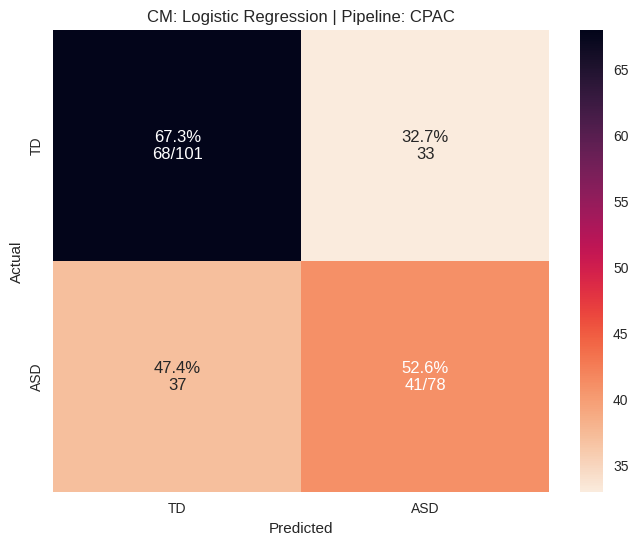

Matrica spremljena kao: cm_cpac_logistic_regression.pdf

--- Model: Random Forest (CPAC) ---


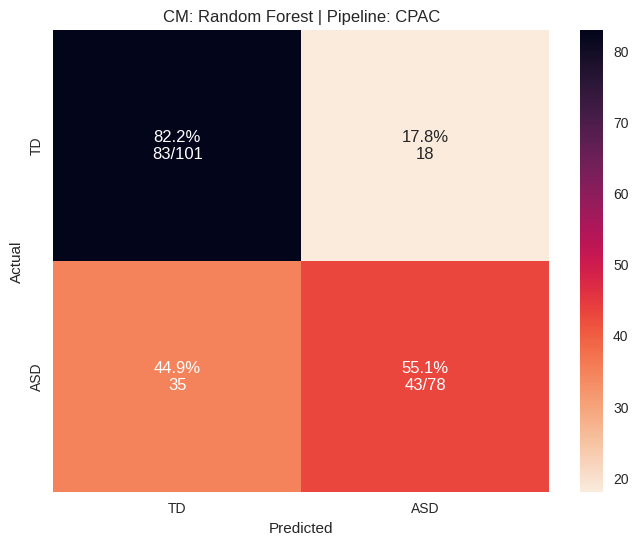

Matrica spremljena kao: cm_cpac_random_forest.pdf

--- Model: Naive Bayes (CPAC) ---


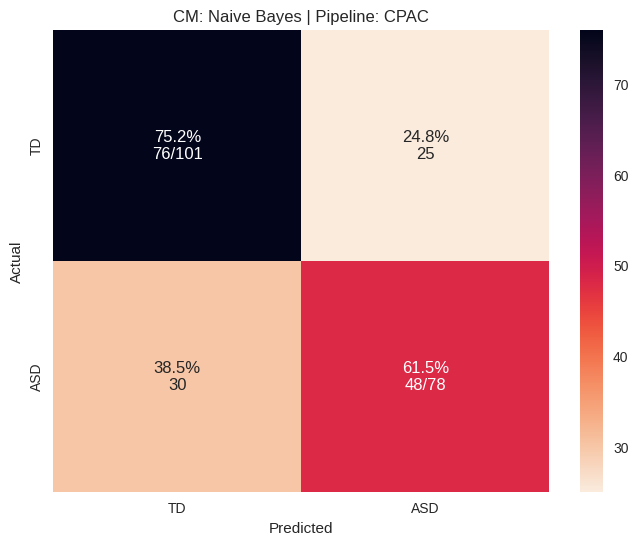

Matrica spremljena kao: cm_cpac_naive_bayes.pdf

--- Model: MLP (CPAC) ---


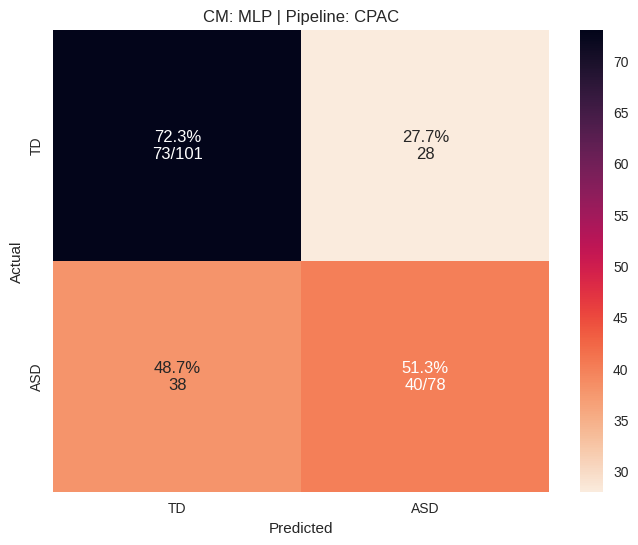

Matrica spremljena kao: cm_cpac_mlp.pdf

############################################################
 GENERIRAM CONFUSION MATRICE ZA PIPELINE: CCS 
############################################################

--- Model: Logistic Regression (CCS) ---


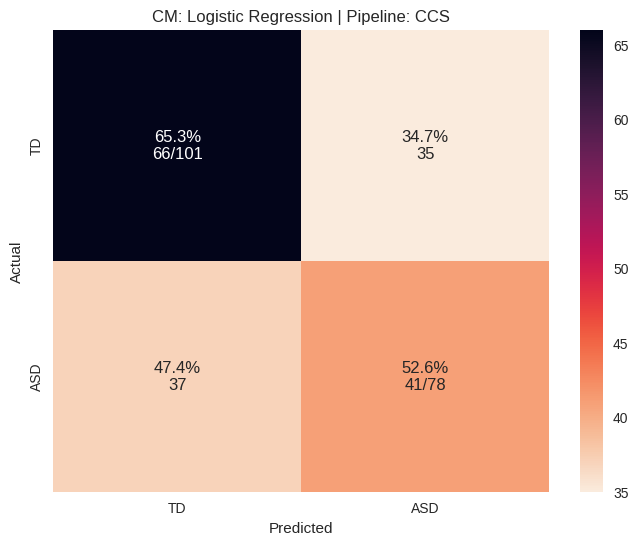

Matrica spremljena kao: cm_ccs_logistic_regression.pdf

--- Model: Random Forest (CCS) ---


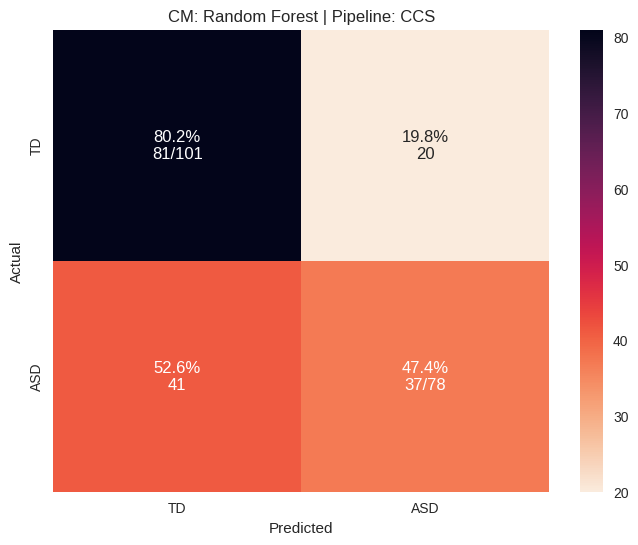

Matrica spremljena kao: cm_ccs_random_forest.pdf

--- Model: Naive Bayes (CCS) ---


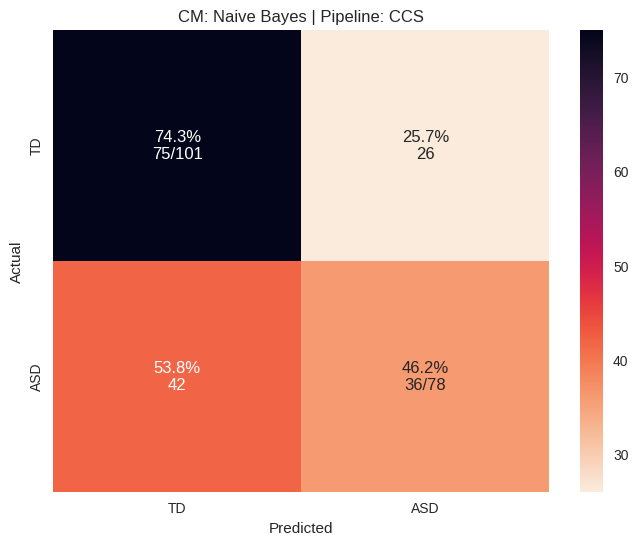

Matrica spremljena kao: cm_ccs_naive_bayes.pdf

--- Model: MLP (CCS) ---


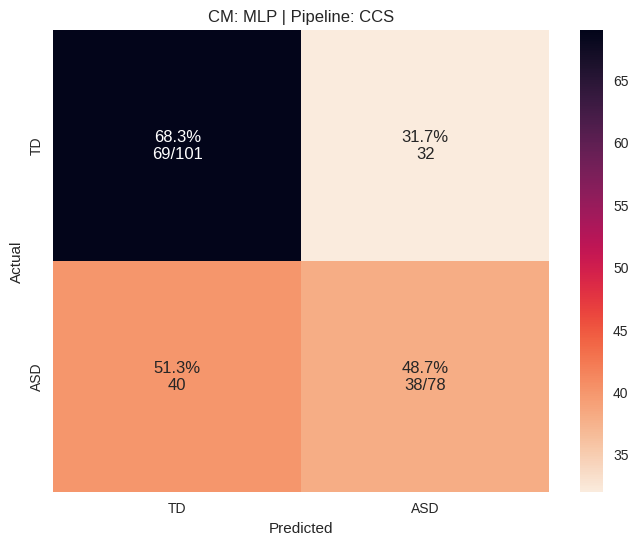

Matrica spremljena kao: cm_ccs_mlp.pdf

############################################################
 GENERIRAM CONFUSION MATRICE ZA PIPELINE: NIAK 
############################################################

--- Model: Logistic Regression (NIAK) ---


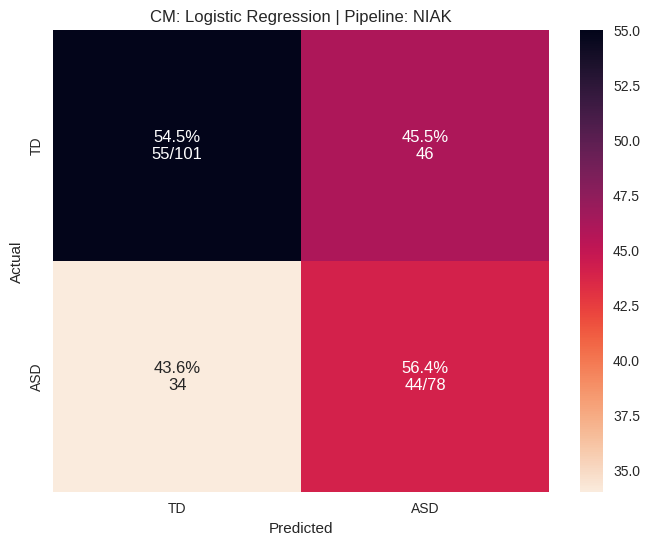

Matrica spremljena kao: cm_niak_logistic_regression.pdf

--- Model: Random Forest (NIAK) ---


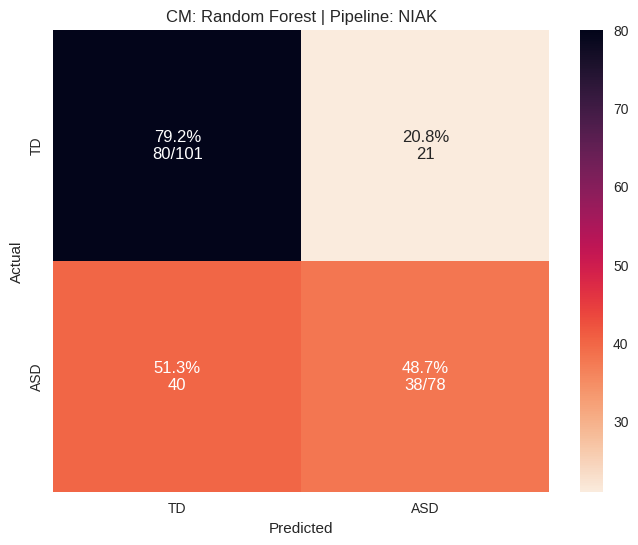

Matrica spremljena kao: cm_niak_random_forest.pdf

--- Model: Naive Bayes (NIAK) ---


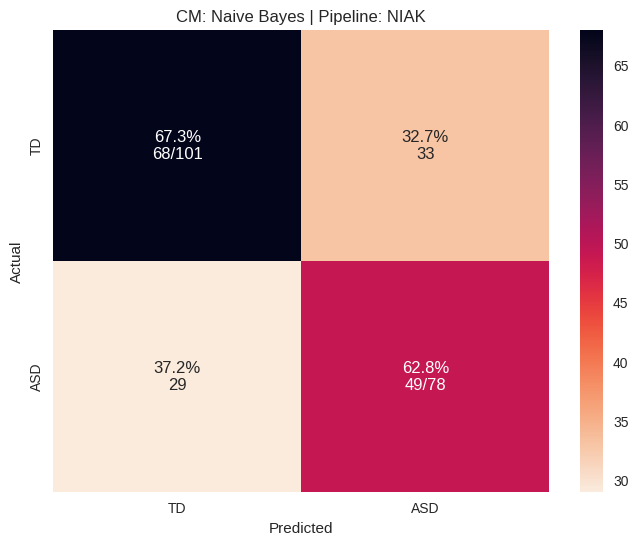

Matrica spremljena kao: cm_niak_naive_bayes.pdf

--- Model: MLP (NIAK) ---


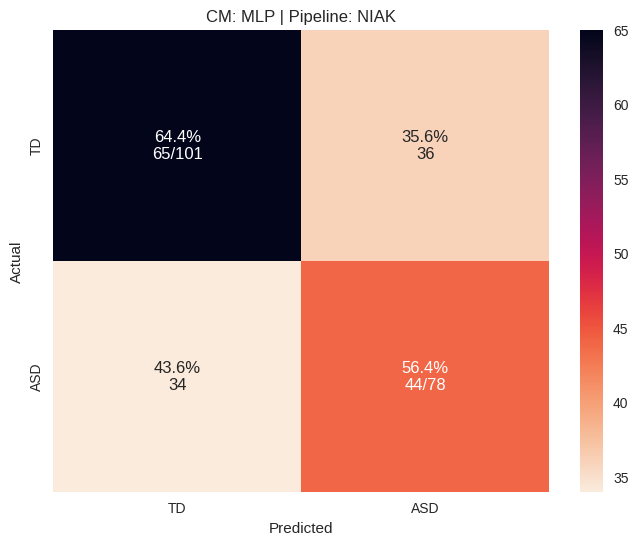

Matrica spremljena kao: cm_niak_mlp.pdf


In [ ]:
# Confusion Matrix

for pipeline_name, models_predictions in all_predictions.items():
    print(f"\n" + "#"*60)
    print(f" GENERIRAM CONFUSION MATRICE ZA PIPELINE: {pipeline_name} ")
    print("#"*60)

    y_test_actual = processed_data[pipeline_name]['y_test']

    for model_name, preds in models_predictions.items():

        clean_pipeline_name = pipeline_name.lower()
        clean_model_name = model_name.lower().replace(" ", "_")
        file_name = f'cm_{clean_pipeline_name}_{clean_model_name}.pdf'

        print(f"\n--- Model: {model_name} ({pipeline_name}) ---")

        plot_confusion_matrix_detailed(
            y_test_actual,
            preds['y_pred'],
            title=f'CM: {model_name} | Pipeline: {pipeline_name}',
            save_path=file_name
        )

        print(f"Matrica spremljena kao: {file_name}")
        # Kopiranje specifične datoteke na Drive
        #!cp {file_name} /content/drive/MyDrive/ABIDE/


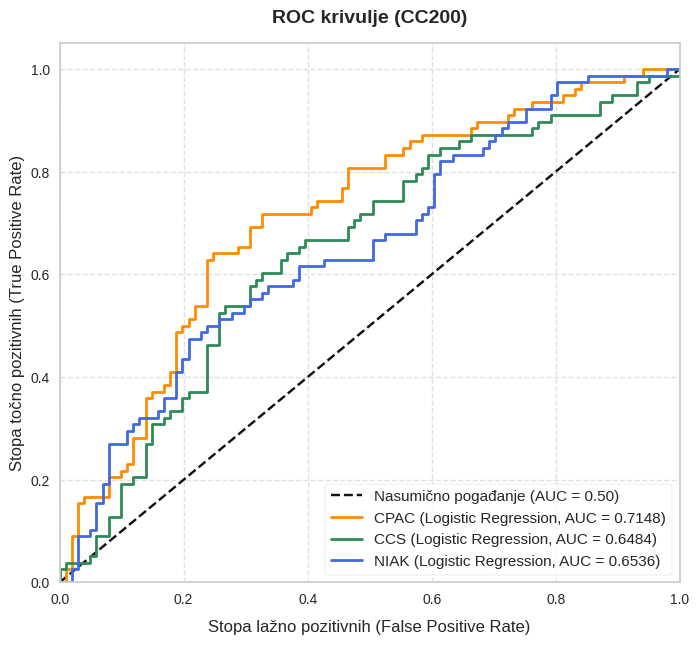

In [ ]:
# ROC Krivulje
import matplotlib.pyplot as plt
from sklearn.metrics iCurvesmport roc_curve, auc

plt.figure(figsize=(8, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Nasumično pogađanje (AUC = 0.50)') # Dijagonala

# --- 1. CPAC ---
p1 = 'CPAC'
m1 = 'Logistic Regression'  #'Logistic Regression' 'Naive Bayes'
if 'y_prob' in all_predictions[p1][m1]:
    # sklearn roc_curve zahtijeva vjerojatnosti za pozitivnu klasu (indeks 1)
    # Ako ti je y_prob 2D matrica, uzimamo [:, 1], ako je 1D, samo proslijedi preds
    probs1 = all_predictions[p1][m1]['y_prob'][:, 1] if all_predictions[p1][m1]['y_prob'].ndim > 1 else all_predictions[p1][m1]['y_prob']
    fpr1, tpr1, _ = roc_curve(processed_data[p1]['y_test'], probs1)
    roc_auc1 = auc(fpr1, tpr1)
    plt.plot(fpr1, tpr1, label=f'{p1} ({m1}, AUC = {roc_auc1:.4f})', color='darkorange', lw=2)

# --- 2. CCS (Logistic Regression) ---
p2 = 'CCS'
m2 = 'Logistic Regression'  #'Random Forest'
if 'y_prob' in all_predictions[p2][m2]:
    probs2 = all_predictions[p2][m2]['y_prob'][:, 1] if all_predictions[p2][m2]['y_prob'].ndim > 1 else all_predictions[p2][m2]['y_prob']
    fpr2, tpr2, _ = roc_curve(processed_data[p2]['y_test'], probs2)
    roc_auc2 = auc(fpr2, tpr2)
    plt.plot(fpr2, tpr2, label=f'{p2} ({m2}, AUC = {roc_auc2:.4f})', color='seagreen', lw=2)

# --- 3. NIAK (Naive Bayes) ---
p3 = 'NIAK'
m3 = 'Logistic Regression'
if 'y_prob' in all_predictions[p3][m3]:
    probs3 = all_predictions[p3][m3]['y_prob'][:, 1] if all_predictions[p3][m3]['y_prob'].ndim > 1 else all_predictions[p3][m3]['y_prob']
    fpr3, tpr3, _ = roc_curve(processed_data[p3]['y_test'], probs3)
    roc_auc3 = auc(fpr3, tpr3)
    plt.plot(fpr3, tpr3, label=f'{p3} ({m3}, AUC = {roc_auc3:.4f})', color='royalblue', lw=2)

# Estetika grafa
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Stopa lažno pozitivnih (False Positive Rate)', fontsize=12, labelpad=10)
plt.ylabel('Stopa točno pozitivnih (True Positive Rate)', fontsize=12)
plt.title('ROC krivulje (CC200)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)

# Spremanje kao PDF
#plt.savefig('zajednicke_roc_krivulje.pdf', bbox_inches='tight')
#!cp zajednicke_roc_krivulje.pdf /content/drive/MyDrive/ABIDE/
#plt.show()


Generiram Learning Curve za: CPAC (Model: Logistic Regression)


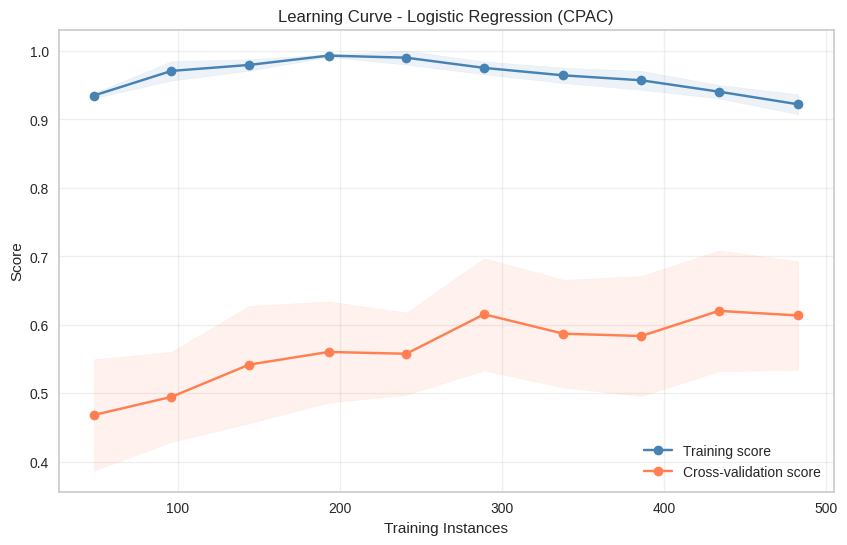


Generiram Learning Curve za: CCS (Model: Logistic Regression)


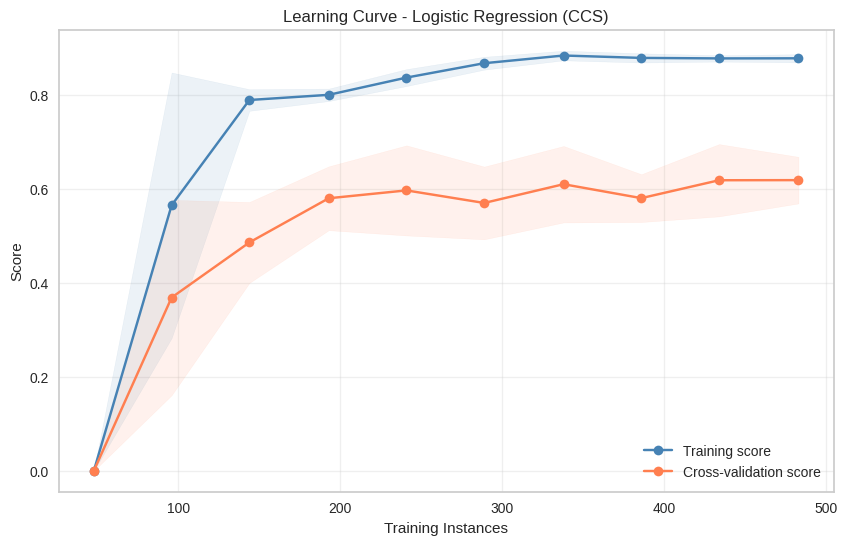


Generiram Learning Curve za: NIAK (Model: Logistic Regression)


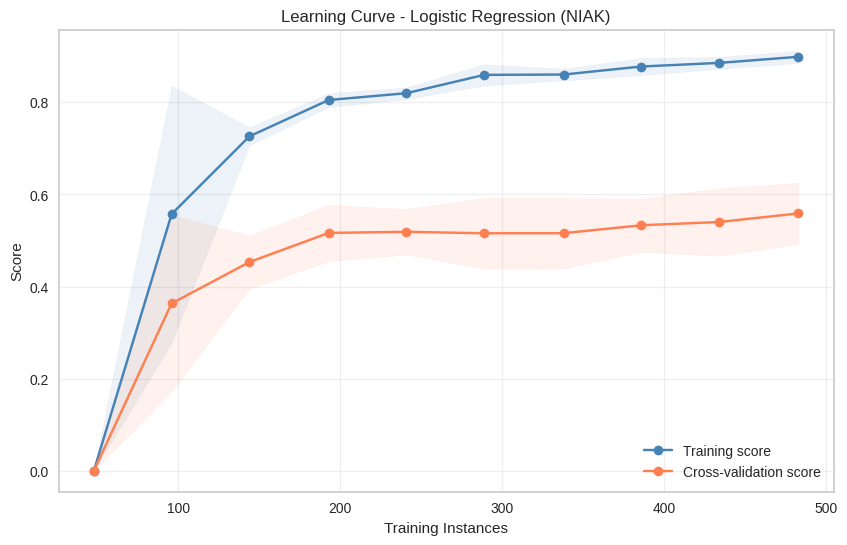


Sve Learning krivulje su generirane i kopirane na Drive!


In [ ]:
# [GSR = True] Learning Curve
from sklearn.preprocessing import StandardScaler

# Lista tvojih pipelineova
pipelines = ['CPAC', 'CCS', 'NIAK']

for pipe in pipelines:
    print(f"\n{'='*50}")

    # Određivanje modela ovisno o pipelineu
    #if pipe == 'CCS':
    #     model_key = 'Logistic Regression'
    #else:
    model_key = 'Logistic Regression'

    print(f"Generiram Learning Curve za: {pipe} (Model: {model_key})")
    print('='*50)

    # 1. Dohvaćanje modela
    best_model_abide = all_best_models[pipe][model_key]

    # 2. Dohvaćanje podataka za trenutni pipeline
    X_abide = processed_data[pipe]['X_train']
    y_abide = processed_data[pipe]['y_train']

    # 3. Skaliranje
    scaler_abide = StandardScaler()
    X_abide_scaled = scaler_abide.fit_transform(X_abide)

    # 4. Poziv funkcije za crtanje
    file_name = f'learning_curve_{model_key.lower().replace(" ", "_")}_{pipe.lower()}.pdf'

    plot_learning_curve_sklearn(
        best_model_abide,
        X_abide_scaled,
        y_abide,
        title=f'Learning Curve - {model_key} ({pipe})',
        cv=10,
        save_path=file_name
    )

    # Kopiranje točno te datoteke na Drive
    #!cp {file_name} /content/drive/MyDrive/ABIDE_gsrFalse/
    #print(f"Uspješno spremljeno: {file_name}")

print("\nSve Learning krivulje su generirane i kopirane na Drive!")